In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json
import numpy as np
import math

log_name = 'new_local'
other_log_name = 'new_long'

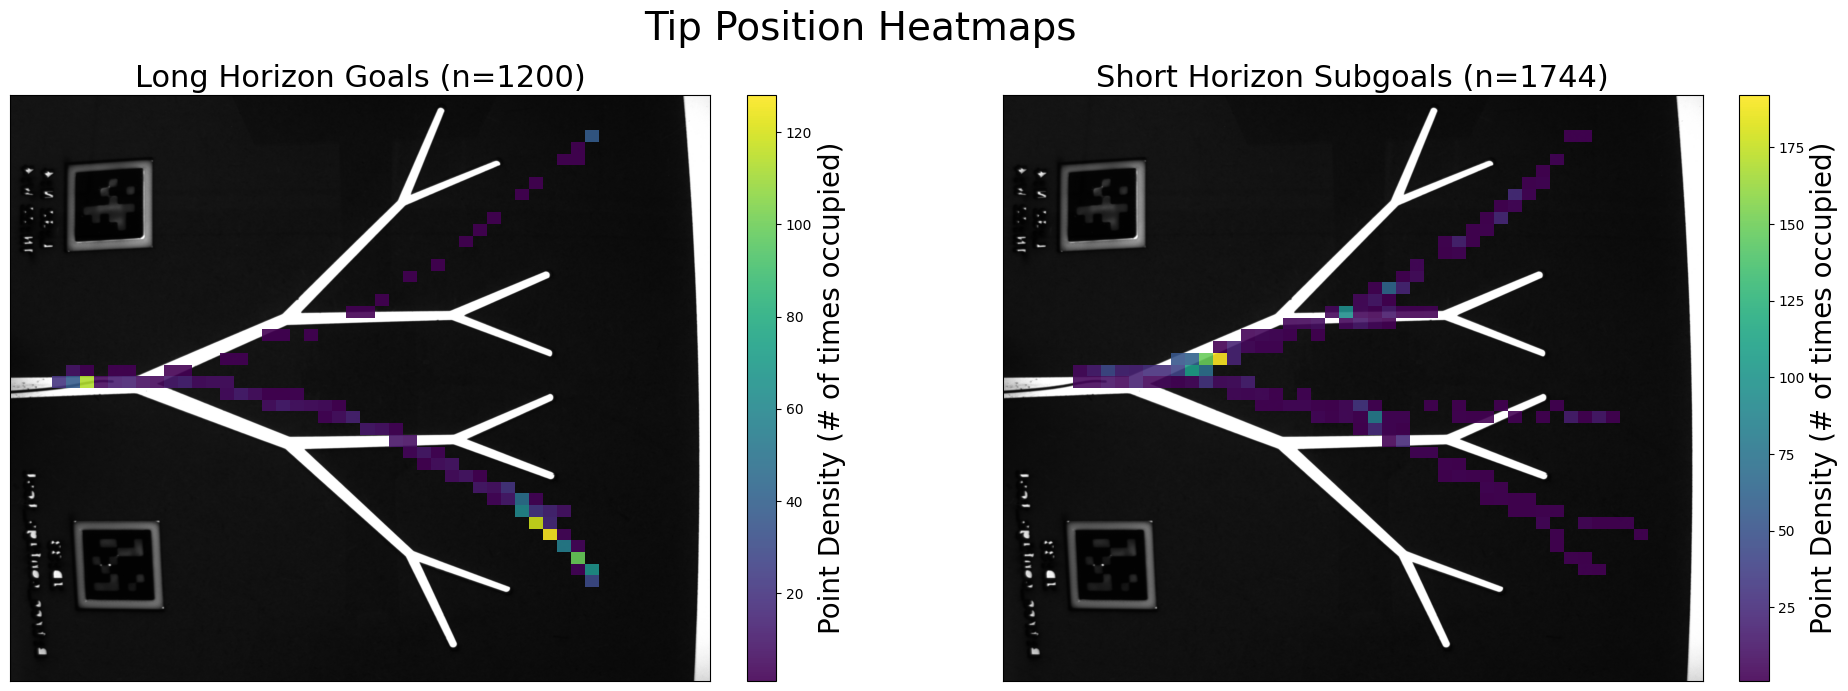

In [23]:
def plot_heatmap_on_ax(log_name, ax, img, plot_title=''):
    x_coords = []
    y_coords = []

    try:
        with open(f'catheter_log_{log_name}.jsonl', 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    # Extract coordinates
                    x_coords.append(data['tip_xy'][0])
                    y_coords.append(data['tip_xy'][1]) 
                except (json.JSONDecodeError, KeyError):
                    continue
    except FileNotFoundError:
        ax.set_title(f"File not found")
        return

    h, w = img.shape[:2]
    ax.imshow(img, extent=[0, w, h, 0], aspect='auto', zorder=1, cmap='gray')

    if len(x_coords) > 0:
        heatmap, xedges, yedges = np.histogram2d(
            x_coords, y_coords, 
            bins=50, 
            range=[[0, w], [0, h]]
        )
        heatmap = np.ma.masked_where(heatmap == 0, heatmap)

        ax.imshow(heatmap.T, 
                  extent=[0, w, h, 0], 
                  alpha=0.9,  
                  origin='upper', 
                  zorder=2)
        
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    
    ax.set_title(f"{plot_title} (n={len(x_coords)})", fontsize=22)

bg_img = mpimg.imread('../src/oldbackground.png')
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(20, 7))

plot_heatmap_on_ax(log_name, ax1, bg_img, plot_title="Short Horizon Subgoals")
if other_log_name:
    plot_heatmap_on_ax(other_log_name, ax2, bg_img, plot_title="Long Horizon Goals")
    x = fig.colorbar(ax2.images[1], ax=ax2, fraction=0.046, pad=0.04, label='Point Density (# of times occupied)')
    x.set_label('Point Density (# of times occupied)', fontsize=20)

x = fig.colorbar(ax1.images[1], ax=ax1, fraction=0.046, pad=0.04, label='Point Density (# of times occupied)')
x.set_label('Point Density (# of times occupied)', fontsize=20)

plt.suptitle("Tip Position Heatmaps", fontsize=28)
plt.tight_layout()
plt.savefig('tip_position_heatmaps.png', dpi=300)
plt.show()

In [27]:
precomputed_goals = [
    [(269, 1019), (383, 1015), (466, 1004), (549, 973), (623, 934), (691, 907), (770, 875), (842, 839), (933, 801), (1024, 739), (1081, 682), (1122, 638), (1170, 591), (1226, 536), (1287, 466), (1340, 413), (1376, 373), (1395, 328), (1412, 292), (1431, 243), (1463, 186), (1484, 137), (1491, 108), (1506, 63)],
    [(301, 1032), (403, 1015), (477, 1017), (540, 1049), (617, 1083), (683, 1113), (748, 1140), (801, 1161), (873, 1178), (924, 1197), (986, 1221), (1050, 1214), (1117, 1212), (1164, 1221), (1268, 1214), (1353, 1216), (1431, 1216), (1491, 1212), (1563, 1208), (1629, 1180), (1692, 1151), (1752, 1125), (1807, 1102), (1851, 1081), (1890, 1064)],
    [(273, 1026), (379, 1015), (470, 1004), (543, 977), (627, 928), (712, 903), (791, 867), (848, 841), (931, 809), (1011, 752), (1058, 697), (1094, 659), (1134, 619), (1187, 566), (1249, 504), (1294, 457), (1332, 419), (1376, 377), (1431, 362), (1482, 341), (1529, 318), (1576, 298), (1637, 273), (1701, 248)], 
    [(284, 1011), (364, 1028), (428, 1019), (502, 1015), (528, 1051), (576, 1074), (642, 1098), (702, 1113), (761, 1136), (801, 1153), (850, 1174), (899, 1180), (960, 1208), (1016, 1225), (1067, 1223), (1141, 1221), (1207, 1223), (1289, 1221), (1357, 1219), (1412, 1223), (1440, 1221), (1497, 1210), (1550, 1208), (1599, 1227), (1644, 1242), (1684, 1261), (1739, 1280), (1788, 1295), (1832, 1312), (1894, 1333)],
    [(256, 1019), (350, 1007), (458, 1009), (566, 968), (636, 930), (725, 892), (791, 862), (871, 828), (952, 790), (1018, 786), (1079, 786), (1143, 786), (1217, 784), (1289, 784), (1357, 786), (1412, 778), (1465, 775), (1514, 773), (1561, 771), (1599, 754), (1644, 729), (1697, 712), (1754, 689), (1809, 667), (1851, 644), (1877, 638)],
    [(238, 1012), (335, 1004), (381, 1014), (447, 1021), (447, 1021), (517, 1037), (574, 1057), (629, 1078), (692, 1110), (759, 1131), (812, 1157), (876, 1182), (950, 1205), (993, 1223), (1021, 1253), (1060, 1299), (1102, 1332), (1145, 1375), (1196, 1415), (1246, 1459), (1300, 1511), (1348, 1553), (1380, 1581), (1403, 1597), (1518, 1645), (1578, 1666), (1629, 1685), (1686, 1701), (1719, 1728)],
    [(250, 1030), (345, 1024), (458, 1011), (553, 981), (627, 937), (708, 892), (774, 856), (859, 839), (965, 801), (1026, 792), (1081, 786), (1145, 784), (1232, 788), (1291, 782), (1342, 784), (1393, 773), (1465, 778), (1520, 773), (1563, 773), (1593, 788), (1629, 807), (1669, 826), (1714, 841), (1769, 860), (1824, 884), (1883, 905)],
    [(292, 1024), (360, 1024), (449, 1026), (513, 1043), (572, 1074), (621, 1089), (661, 1104), (723, 1130), (784, 1149), (835, 1174), (893, 1197), (943, 1214), (999, 1238), (1047, 1282), (1073, 1310), (1111, 1337), (1145, 1375), (1181, 1407), (1228, 1450), (1289, 1494), (1327, 1530), (1364, 1566), (1419, 1649), (1442, 1693), (1465, 1740), (1482, 1780), (1504, 1819), (1552, 1918)]
]

precomputed_goals = [
    [(416, 979), (526, 975), (618, 964), (724, 915), (818, 889), (919, 853), (1020, 827), (1126, 792), (1207, 765), (1272, 732), (1341, 683), (1403, 646), (1478, 601), (1564, 545), (1652, 489), (1730, 436), (1796, 395), (1850, 324), (1910, 264), (1955, 221), (1990, 178), (2046, 116)],
    [(410, 960), (511, 958), (603, 943), (726, 904), (831, 893), (924, 857), (1027, 825), (1134, 797), (1210, 771), (1280, 728), (1341, 687), (1412, 640), (1474, 612), (1553, 558), (1648, 507), (1712, 453), (1781, 412), (1837, 401), (1906, 380), (1979, 356), (2063, 328), (2155, 303)],
    [(404, 975), (505, 979), (597, 956), (709, 917), (829, 878), (937, 844), (1042, 825), (1145, 795), (1222, 767), (1293, 775), (1388, 767), (1448, 765), (1545, 765), (1654, 760), (1762, 752), (1850, 750), (1923, 726), (1985, 707), (2080, 687), (2187, 653), (2263, 633)],
    [(425, 969), (530, 956), (623, 947), (737, 917), (842, 893), (941, 851), (1059, 823), (1160, 797), (1240, 765), (1302, 769), (1384, 767), (1429, 760), (1575, 760), (1680, 760), (1755, 750), (1824, 752), (1882, 752), (1934, 773), (2009, 782), (2101, 808), (2271, 848)],
    [(436, 984), (517, 982), (621, 990), (715, 1016), (803, 1035), (902, 1053), (997, 1078), (1098, 1100), (1201, 1115), (1272, 1113), (1356, 1104), (1521, 1104), (1654, 1104), (1788, 1102), (1899, 1095), (2007, 1059), (2093, 1020), (2181, 1010), (2276, 967)],
    [(397, 986), (485, 973), (629, 994), (732, 997), (831, 1018), (911, 1035), (999, 1057), (1117, 1093), (1207, 1121), (1278, 1126), (1349, 1119), (1487, 1117), (1577, 1113), (1687, 1102), (1837, 1098), (1904, 1108), (1960, 1123), (2043, 1132), (2151, 1156), (2280, 1184)],
    [(444, 969), (522, 967), (599, 971), (642, 997), (756, 1020), (840, 1031), (932, 1053), (1023, 1085), (1139, 1104), (1225, 1121), (1280, 1158), (1336, 1184), (1414, 1229), (1504, 1267), (1571, 1313), (1650, 1356), (1712, 1390), (1781, 1416), (1829, 1437), (1887, 1444), (1955, 1463), (2024, 1474), (2101, 1502), (2202, 1519)],
    [(449, 984), (530, 975), (653, 994), (743, 1016), (855, 1044), (960, 1061), (1055, 1091), (1164, 1102), (1237, 1136), (1304, 1169), (1366, 1209), (1459, 1248), (1549, 1295), (1611, 1347), (1685, 1373), (1753, 1411), (1829, 1450), (1865, 1495), (1917, 1534), (1975, 1590), (2046, 1656), (2095, 1706)]
]


# easy way to generate long horizon goals
long_horizon_goals = [list(x[-1]) for x in precomputed_goals]


def get_subgoals_for_long_horizon(log_name):
    subgoals_reached_per_ep = []
    with open(f'catheter_log_{log_name}.jsonl', 'r') as f:
        subgoals = None
        subgoal_idx = 0
        for i, line in enumerate(f):
            try:
                data = json.loads(line)
            except:
                print(line)
                continue
            tip_xy = data['tip_xy']

            if data['truncated'] or data['terminated']:
                subgoals = None
                subgoals_reached_per_ep.append(subgoal_idx)
                subgoal_idx = 0
                continue

            if subgoals is None:
                long_goal = [int(data['goal_xy'][0]), int(data['goal_xy'][1])]
                subgoals = precomputed_goals[long_horizon_goals.index(long_goal)]

            distances = [math.dist(tip_xy, sg) for sg in subgoals]

            reached_indices = [i for i, d in enumerate(distances) if d < 45]
            if reached_indices:
                max_reached = max(reached_indices)

                subgoal_idx = max(max_reached, subgoal_idx)
    return subgoals_reached_per_ep

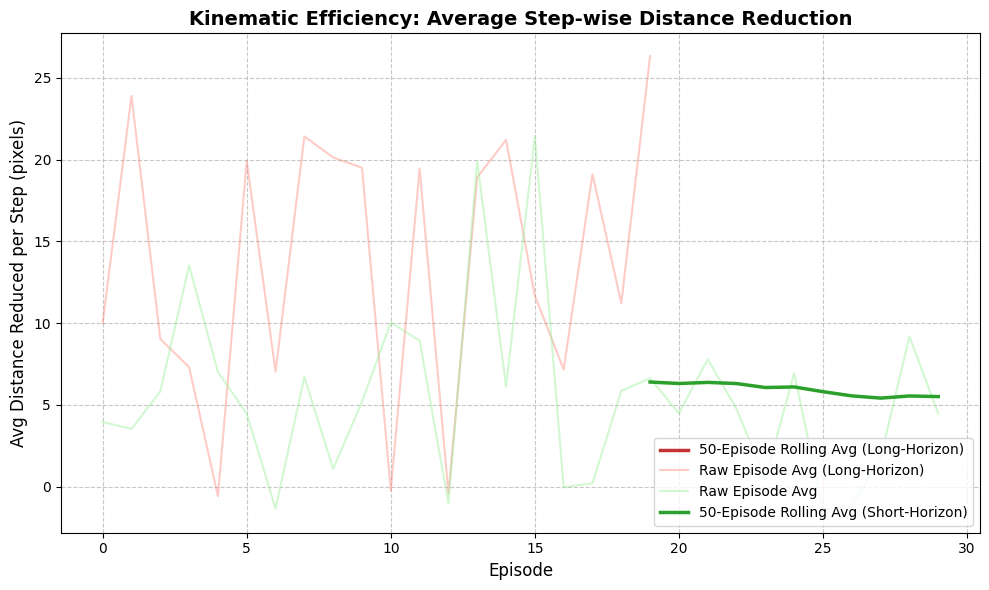

In [28]:
def get_data(log_name):
    episodes = []
    current_episode = []

    with open(f'catheter_log_{log_name}.jsonl', 'r') as f:
        for line in f:
            try:
                data = json.loads(line)
            except:
                print(line)
            current_episode.append(data)
            if data.get('terminated') or data.get('truncated') or data.get('step') == 60:
                episodes.append(current_episode)
                current_episode = []

    avg_step_reductions = []
    subgoals_reached_per_ep = []

    for ep in episodes:
        if len(ep) < 2:
            continue
            
        step_reductions = []
        goal_shifts = 0
        prev_dist = None

        for i in range(1, len(ep) - 1):
            prev_goal = ep[i-1]['goal_xy']
            curr_goal = ep[i]['goal_xy']
            
            goal_moved = math.dist(prev_goal, curr_goal) > 0.1
            
            if goal_moved:
                goal_shifts += 1
                if prev_dist is not None:
                    step_reductions.append(prev_dist)
                else:
                    step_reductions.append(0)
                continue
                
            prev_dist = ep[i-1]['dist_px']
            curr_dist = ep[i]['dist_px']
            
            reduction = prev_dist - curr_dist 
            step_reductions.append(reduction)

        subgoals_reached_per_ep.append(goal_shifts)
            
        if len(step_reductions) > 0:
            avg_step_reductions.append(np.mean(step_reductions))
        else:
            avg_step_reductions.append(0)

    return avg_step_reductions, subgoals_reached_per_ep

avg_step_reductions, subgoals_reached_per_ep = get_data(log_name)

window_size = 50 
smoothed_reductions = pd.Series(avg_step_reductions).rolling(window=window_size, min_periods=20).mean()

# 4. Plot the data
plt.figure(figsize=(10, 6))

# Plot a dashed line at Y=0. 
# Anything below this line means the robot is failing/moving backwards.
# plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero Progress Baseline')

if other_log_name:
    other_avg_reductions, other_subgoals_reached_per_ep = get_data(other_log_name)
    other_smoothed = pd.Series(other_avg_reductions).rolling(window=window_size, min_periods=20).mean()
    plt.plot(other_smoothed, color="#b30000", linewidth=2.5, alpha=0.8, label='50-Episode Rolling Avg (Long-Horizon)')
    plt.plot(other_avg_reductions, color='salmon', alpha=0.4, label='Raw Episode Avg (Long-Horizon)')

# Raw data in the background
plt.plot(avg_step_reductions, color='lightgreen', alpha=0.4, label='Raw Episode Avg')

plt.plot(smoothed_reductions, color='#2ca02c', linewidth=2.5, label='50-Episode Rolling Avg (Short-Horizon)')



plt.title('Kinematic Efficiency: Average Step-wise Distance Reduction', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Avg Distance Reduced per Step (pixels)', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(f'kinematic_efficiency_{log_name}.png', dpi=300)
plt.show()

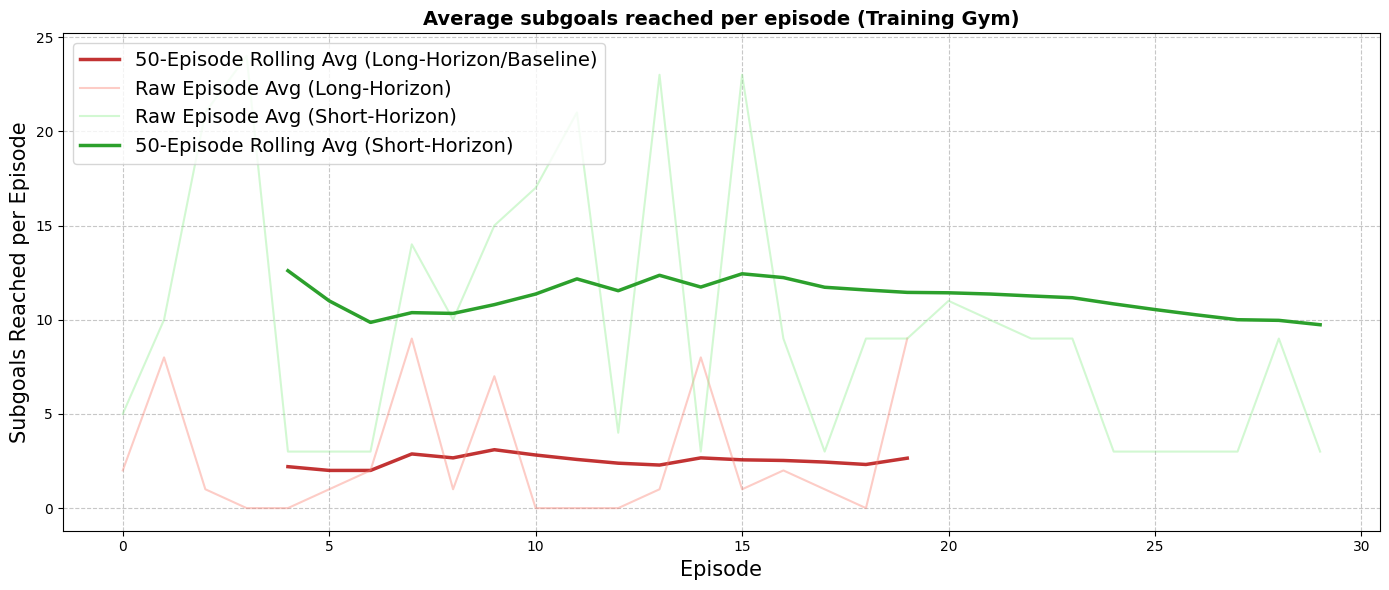

In [29]:
subgoals_reached_per_ep = np.array(subgoals_reached_per_ep)
smoothed_reductions = pd.Series(subgoals_reached_per_ep).rolling(window=window_size, min_periods=5).mean()

# 4. Plot the data
plt.figure(figsize=(14, 6))

# Plot a dashed line at Y=0. 
# Anything below this line means the robot is failing/moving backwards.
# plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero Progress Baseline')


if other_log_name:
    # other_avg_reductions, other_subgoals_reached_per_ep = get_data(other_log_name)
    other_subgoals_reached_per_ep = get_subgoals_for_long_horizon(other_log_name)
    other_smoothed = pd.Series(other_subgoals_reached_per_ep).rolling(window=window_size, min_periods=5).mean()
    plt.plot(other_smoothed, color="#b30000", linewidth=2.5, alpha=0.8, label='50-Episode Rolling Avg (Long-Horizon/Baseline)')
    plt.plot(other_subgoals_reached_per_ep, color='salmon', alpha=0.4, label='Raw Episode Avg (Long-Horizon)')

# Raw data in the background
plt.plot(subgoals_reached_per_ep, color='lightgreen', alpha=0.4, label='Raw Episode Avg (Short-Horizon)')

# Smoothed trendline
plt.plot(smoothed_reductions, color='#2ca02c', linewidth=2.5, label='50-Episode Rolling Avg (Short-Horizon)')

plt.title('Average subgoals reached per episode (Training Gym)', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=15)
plt.ylabel('Subgoals Reached per Episode', fontsize=15)
plt.legend(loc='upper left', frameon=True, fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(f'kinematic_efficiency_{log_name}.png', dpi=300)
plt.show()

/tmp/ipykernel_25871/435265346.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


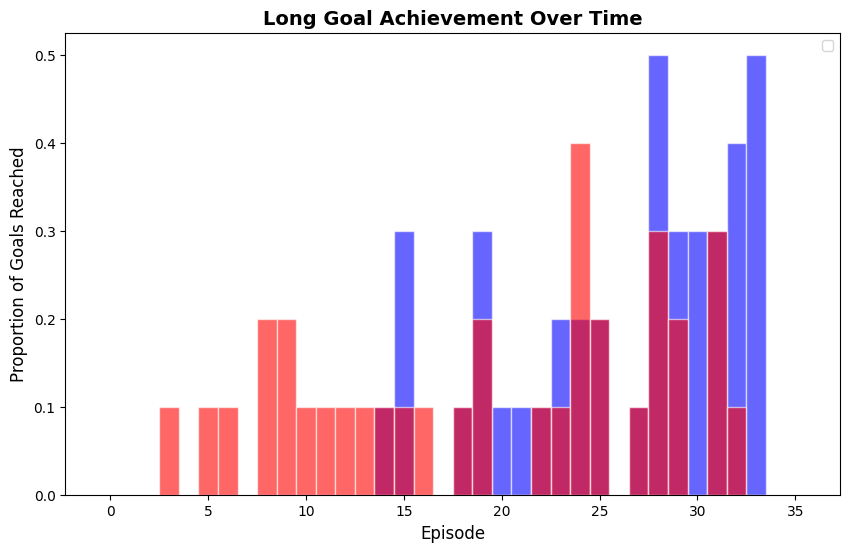

In [37]:
def long_goals_over_time(log_name, chunk_size=10):
    goals_over_time = []
    with open(f'catheter_log_{log_name}.jsonl', 'r') as f:
        for line in f:
            try:
                data = json.loads(line)
            except:
                print(line)
                continue
            if data.get('terminated'):
                goals_over_time.append(1)
            elif data.get('truncated'):
                goals_over_time.append(0)

    counts = [np.sum(goals_over_time[i:i+chunk_size]) / chunk_size for i in range(0, len(goals_over_time), chunk_size)]
    return counts

binned_goals = long_goals_over_time(log_name, chunk_size=10)
other_binned_goals = long_goals_over_time(other_log_name, chunk_size=10) if other_log_name else None

# goals_over_time_binned = np.histogram(goals_over_time, bins=10)[0]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(range(len(binned_goals)), binned_goals, width=1.0, edgecolor='white', color='blue', alpha=0.6)
if other_binned_goals is not None:
    ax.bar(range(len(other_binned_goals)), other_binned_goals, width=1.0, edgecolor='white', color='red', alpha=0.6)
plt.title('Long Goal Achievement Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Proportion of Goals Reached', fontsize=12)
plt.legend(loc='upper right')
plt.show()

In [20]:
from pathlib import Path
from PIL import Image

def make_gif_from_folder(folder_path, output_filename=None, frame_duration=200, loop_count=0):
    image_files = sorted(Path(folder_path).glob('step_*.png')) 
    
    frames = []
    for img_file in image_files:
        img = Image.open(img_file)

        if img.mode == 'RGBA':
            bg = Image.new('RGB', img.size, (255, 255, 255))
            bg.paste(img, mask=img.split()[3]) # Use alpha channel as mask
            img = bg
        elif img.mode != 'RGB':
            img = img.convert('RGB')
        
        img.thumbnail((400, 400))

        img = img.convert('P', palette=Image.ADAPTIVE)

        frames.append(img)

    if output_filename is None:
        output_filename = f'{folder_path}.gif'

    frames[0].save(
        output_filename,
        save_all=True,
        append_images=frames[1:],
        duration=frame_duration,
        loop=loop_count
    )

make_gif_from_folder('../training_videos_local_goals_2/episode_0225', 'episode_test.gif')

In [28]:
import imageio.v2 as imageio
from PIL import Image
import numpy as np
from pathlib import Path

def make_mp4_resized(folder_path, output_filename=None, fps=5, target_size=(400, 400)):
    image_files = sorted(Path(folder_path).glob('step_*.png'))
    
    # Default to .mp4 if no filename is provided
    if output_filename is None:
        output_filename = f'{folder_path}.mp4'
        
    frames = []
    for img_file in image_files:
        with Image.open(img_file) as img:
            
            # Safely handle transparency if it exists
            if img.mode == 'RGBA':
                bg = Image.new('RGB', img.size, (255, 255, 255))
                bg.paste(img, mask=img.split()[3])
                img = bg
            elif img.mode != 'RGB':
                img = img.convert('RGB')
                
            # Downscale the image to save RAM and output file size
            img.thumbnail(target_size, Image.Resampling.LANCZOS)
            
            # Convert to numpy array and add to our video frames
            frames.append(np.array(img))

    print(f"Rendering {len(frames)} frames to {output_filename}...")
    
    # Save the video. 
    # 'macro_block_size=1' is a crucial fix for MP4s: H264 video encoders 
    # normally crash if your image width/height aren't perfectly divisible by 16.
    imageio.mimwrite(output_filename, frames)
    
    print("Done!")

# Run it
make_mp4_resized(
    folder_path='../training_videos_local_goals_2/episode_0225', 
    output_filename='episode_test.mp4', # Make sure this ends in .mp4!
    target_size=(400, 400) 
)

Rendering 41 frames to episode_test.mp4...
Done!


In [24]:
from PIL import Image

img = Image.open('../training_videos_local_goals_2/episode_0225/step_000.png')
print(f"Image Mode: {img.mode}")
print(f"Extrema (Min/Max pixel values): {img.getextrema()}")

Image Mode: RGB
Extrema (Min/Max pixel values): ((0, 255), (0, 255), (0, 255))


In [24]:
precomputed_goals_1 = [
    [(269, 1019), (383, 1015), (466, 1004), (549, 973), (623, 934), (691, 907), (770, 875), (842, 839), (933, 801), (1024, 739), (1081, 682), (1122, 638), (1170, 591), (1226, 536), (1287, 466), (1340, 413), (1376, 373), (1395, 328), (1412, 292), (1431, 243), (1463, 186), (1484, 137), (1491, 108), (1506, 63)],
    [(301, 1032), (403, 1015), (477, 1017), (540, 1049), (617, 1083), (683, 1113), (748, 1140), (801, 1161), (873, 1178), (924, 1197), (986, 1221), (1050, 1214), (1117, 1212), (1164, 1221), (1268, 1214), (1353, 1216), (1431, 1216), (1491, 1212), (1563, 1208), (1629, 1180), (1692, 1151), (1752, 1125), (1807, 1102), (1851, 1081), (1890, 1064)],
    [(273, 1026), (379, 1015), (470, 1004), (543, 977), (627, 928), (712, 903), (791, 867), (848, 841), (931, 809), (1011, 752), (1058, 697), (1094, 659), (1134, 619), (1187, 566), (1249, 504), (1294, 457), (1332, 419), (1376, 377), (1431, 362), (1482, 341), (1529, 318), (1576, 298), (1637, 273), (1701, 248)], 
    [(284, 1011), (364, 1028), (428, 1019), (502, 1015), (528, 1051), (576, 1074), (642, 1098), (702, 1113), (761, 1136), (801, 1153), (850, 1174), (899, 1180), (960, 1208), (1016, 1225), (1067, 1223), (1141, 1221), (1207, 1223), (1289, 1221), (1357, 1219), (1412, 1223), (1440, 1221), (1497, 1210), (1550, 1208), (1599, 1227), (1644, 1242), (1684, 1261), (1739, 1280), (1788, 1295), (1832, 1312), (1894, 1333)],
    [(256, 1019), (350, 1007), (458, 1009), (566, 968), (636, 930), (725, 892), (791, 862), (871, 828), (952, 790), (1018, 786), (1079, 786), (1143, 786), (1217, 784), (1289, 784), (1357, 786), (1412, 778), (1465, 775), (1514, 773), (1561, 771), (1599, 754), (1644, 729), (1697, 712), (1754, 689), (1809, 667), (1851, 644), (1877, 638)],
    [(238, 1012), (335, 1004), (381, 1014), (447, 1021), (447, 1021), (517, 1037), (574, 1057), (629, 1078), (692, 1110), (759, 1131), (812, 1157), (876, 1182), (950, 1205), (993, 1223), (1021, 1253), (1060, 1299), (1102, 1332), (1145, 1375), (1196, 1415), (1246, 1459), (1300, 1511), (1348, 1553), (1380, 1581), (1403, 1597), (1518, 1645), (1578, 1666), (1629, 1685), (1686, 1701), (1719, 1728)],
    [(250, 1030), (345, 1024), (458, 1011), (553, 981), (627, 937), (708, 892), (774, 856), (859, 839), (965, 801), (1026, 792), (1081, 786), (1145, 784), (1232, 788), (1291, 782), (1342, 784), (1393, 773), (1465, 778), (1520, 773), (1563, 773), (1593, 788), (1629, 807), (1669, 826), (1714, 841), (1769, 860), (1824, 884), (1883, 905)],
    [(292, 1024), (360, 1024), (449, 1026), (513, 1043), (572, 1074), (621, 1089), (661, 1104), (723, 1130), (784, 1149), (835, 1174), (893, 1197), (943, 1214), (999, 1238), (1047, 1282), (1073, 1310), (1111, 1337), (1145, 1375), (1181, 1407), (1228, 1450), (1289, 1494), (1327, 1530), (1364, 1566), (1419, 1649), (1442, 1693), (1465, 1740), (1482, 1780), (1504, 1819), (1552, 1918)]
]

precomputed_goals_2 = [
    [(416, 979), (526, 975), (618, 964), (724, 915), (818, 889), (919, 853), (1020, 827), (1126, 792), (1207, 765), (1272, 732), (1341, 683), (1403, 646), (1478, 601), (1564, 545), (1652, 489), (1730, 436), (1796, 395), (1850, 324), (1910, 264), (1955, 221), (1990, 178), (2046, 116)],
    [(410, 960), (511, 958), (603, 943), (726, 904), (831, 893), (924, 857), (1027, 825), (1134, 797), (1210, 771), (1280, 728), (1341, 687), (1412, 640), (1474, 612), (1553, 558), (1648, 507), (1712, 453), (1781, 412), (1837, 401), (1906, 380), (1979, 356), (2063, 328), (2155, 303)],
    [(404, 975), (505, 979), (597, 956), (709, 917), (829, 878), (937, 844), (1042, 825), (1145, 795), (1222, 767), (1293, 775), (1388, 767), (1448, 765), (1545, 765), (1654, 760), (1762, 752), (1850, 750), (1923, 726), (1985, 707), (2080, 687), (2187, 653), (2263, 633)],
    [(425, 969), (530, 956), (623, 947), (737, 917), (842, 893), (941, 851), (1059, 823), (1160, 797), (1240, 765), (1302, 769), (1384, 767), (1429, 760), (1575, 760), (1680, 760), (1755, 750), (1824, 752), (1882, 752), (1934, 773), (2009, 782), (2101, 808), (2271, 848)],
    [(436, 984), (517, 982), (621, 990), (715, 1016), (803, 1035), (902, 1053), (997, 1078), (1098, 1100), (1201, 1115), (1272, 1113), (1356, 1104), (1521, 1104), (1654, 1104), (1788, 1102), (1899, 1095), (2007, 1059), (2093, 1020), (2181, 1010), (2276, 967)],
    [(397, 986), (485, 973), (629, 994), (732, 997), (831, 1018), (911, 1035), (999, 1057), (1117, 1093), (1207, 1121), (1278, 1126), (1349, 1119), (1487, 1117), (1577, 1113), (1687, 1102), (1837, 1098), (1904, 1108), (1960, 1123), (2043, 1132), (2151, 1156), (2280, 1184)],
    [(444, 969), (522, 967), (599, 971), (642, 997), (756, 1020), (840, 1031), (932, 1053), (1023, 1085), (1139, 1104), (1225, 1121), (1280, 1158), (1336, 1184), (1414, 1229), (1504, 1267), (1571, 1313), (1650, 1356), (1712, 1390), (1781, 1416), (1829, 1437), (1887, 1444), (1955, 1463), (2024, 1474), (2101, 1502), (2202, 1519)],
    [(449, 984), (530, 975), (653, 994), (743, 1016), (855, 1044), (960, 1061), (1055, 1091), (1164, 1102), (1237, 1136), (1304, 1169), (1366, 1209), (1459, 1248), (1549, 1295), (1611, 1347), (1685, 1373), (1753, 1411), (1829, 1450), (1865, 1495), (1917, 1534), (1975, 1590), (2046, 1656), (2095, 1706)]
]

avg_length_1 = np.median([len(goals) for goals in precomputed_goals_1])
avg_length_2 = np.median([len(goals) for goals in precomputed_goals_2])

print(f"Average number of subgoals in precomputed_goals_1: {avg_length_1}")
print(f"Average number of subgoals in precomputed_goals_2: {avg_length_2}")


Average number of subgoals in precomputed_goals_1: 26.0
Average number of subgoals in precomputed_goals_2: 21.5


In [28]:
subgoals_reached_per_ep[0:10]

[5, 10, 21, 24, 3, 3, 3, 14, 10, 15]

In [89]:
# import os, pathlib, glob, shutil

# # append the episodes from local goals 3 into the list from 2.

# local_goals_3_episodes = os.listdir('../training_videos')
# local_goals_3_episodes.sort()

# for ep in local_goals_3_episodes:
#     new_episode_index = int(ep.split('_')[1]) + 170
#     shutil.copytree(os.path.join('../training_videos', ep), os.path.join('../training_videos_local_goals_2', f'episode_0{new_episode_index}'))

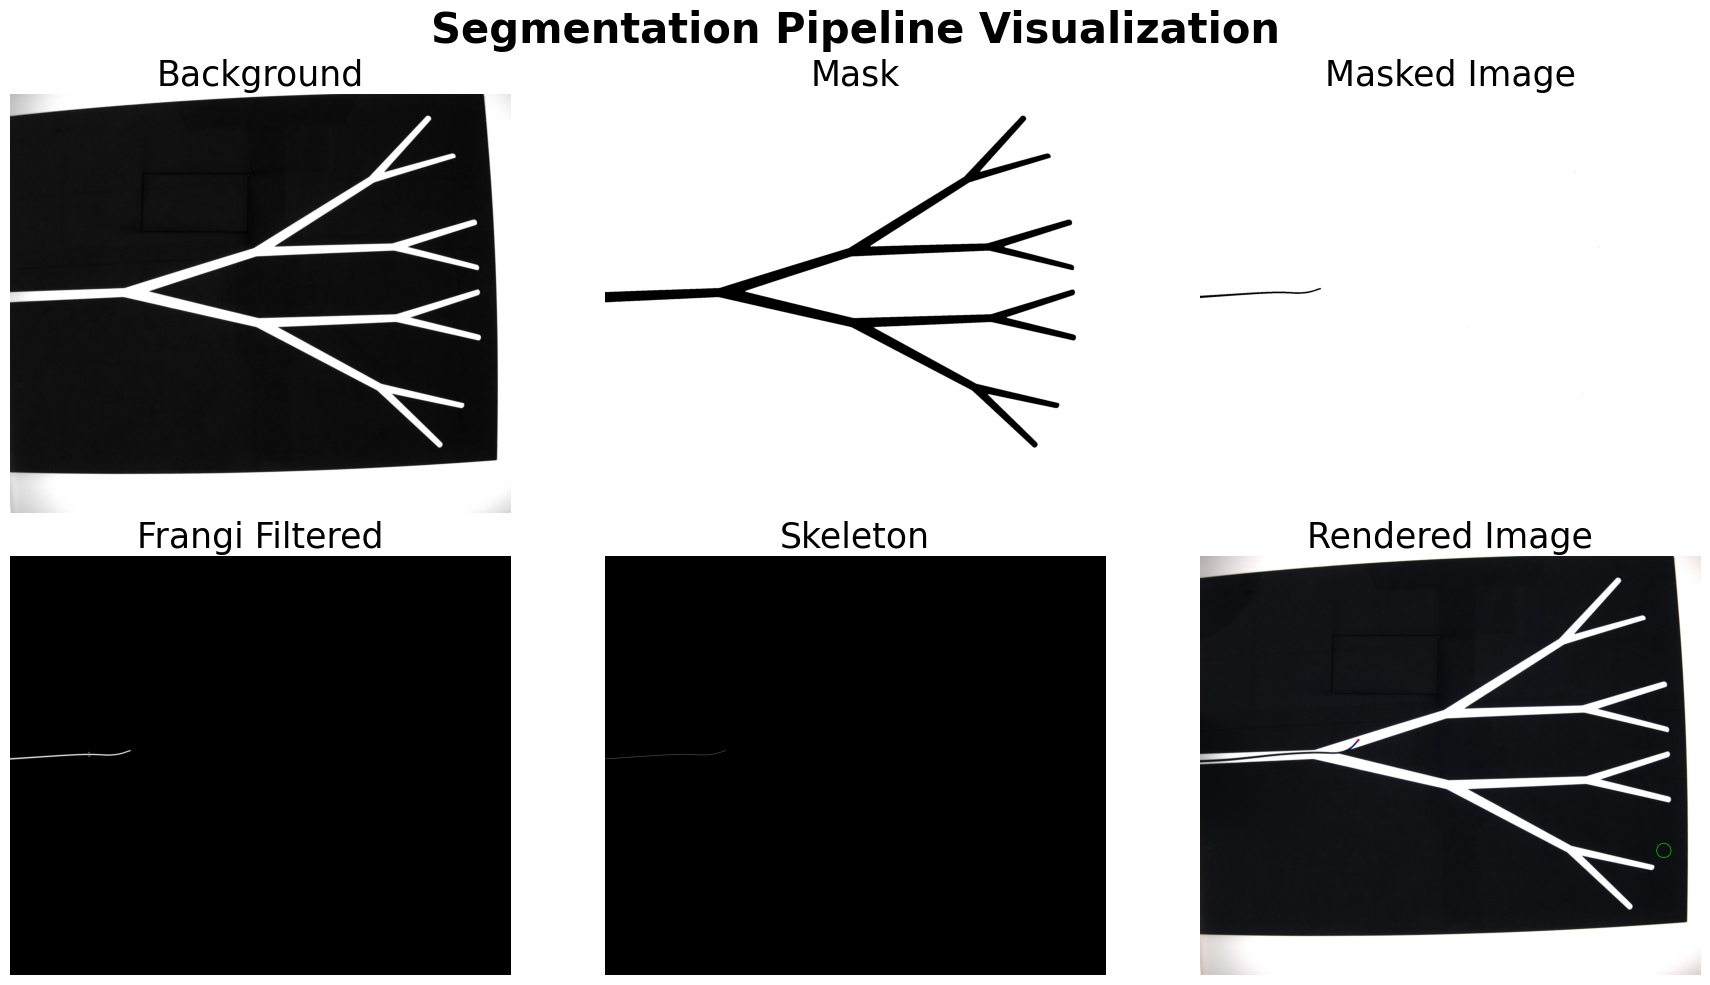

In [21]:
image_list = ["../segPipeline/background.png", "../segPipeline/mask.png", "../segPipeline/masked_image.png", "../segPipeline/frangi_filtered.png", "../segPipeline/skeleton.png", "../segPipeline/render_0001.png"]
label_list = ["Background", "Mask", "Masked Image", "Frangi Filtered", "Skeleton", "Rendered Image"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for img_path, label, ax in zip(image_list, label_list, axes.flatten()):
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=25)
    ax.axis('off')
plt.suptitle("Segmentation Pipeline Visualization", fontsize=30, fontweight='bold')
plt.tight_layout()
plt.savefig('segmentation_pipeline_visualization.png', dpi=300)
plt.show()

/tmp/ipykernel_102533/1034467519.py:10: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  filled_mask = closing(binary_mask, square(15))


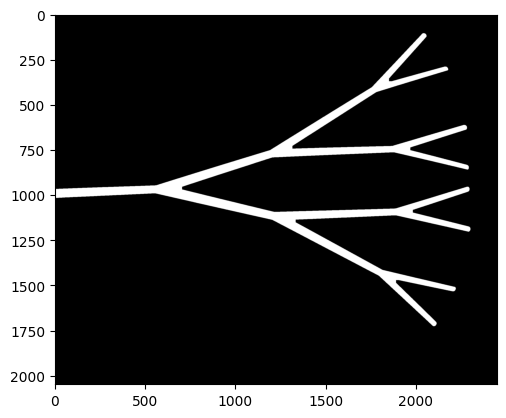

In [17]:
import skimage.morphology
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.morphology import closing, square

image = mpimg.imread('mask.png')

binary_mask = image < 0.5

filled_mask = closing(binary_mask, square(15))

plt.imshow(filled_mask, cmap='gray')

skeleton = skimage.morphology.skeletonize(filled_mask)

skeleton_coords = np.column_stack(np.where(skeleton))

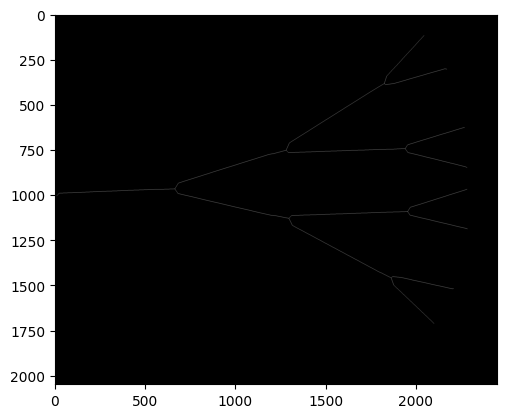

In [18]:
plt.imshow(skeleton, cmap='gray')

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import skimage.morphology
import networkx as nx


nodes = [(r, c) for r, c in skeleton_coords]

start_node = min(nodes, key=lambda coord: coord[1])
print(f"Farthest left pixel (Start Node): {start_node}")

G = nx.Graph()
G.add_nodes_from(nodes)

# Use a set for fast O(1) neighbor lookups
node_set = set(nodes)
for r, c in nodes:
    # Check all 8 surrounding neighbors
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0:
                continue
            neighbor = (r + dr, c + dc)
            if neighbor in node_set:
                G.add_edge((r, c), neighbor)

bifurcations = [node for node, degree in G.degree() if degree > 2]
endpoints = [node for node, degree in G.degree() if degree == 1]
key_nodes = set(bifurcations + endpoints)

print(f"Found {len(bifurcations)} bifurcations and {len(endpoints)} endpoints.")

N = 100  # Set your sampling interval here (e.g., keep 1 node every 10 pixels)

reduced_G = nx.Graph()
reduced_G.add_nodes_from(key_nodes)

visited_edges = set()

# Trace the paths between key nodes
for start_key in key_nodes:
    for neighbor in G.neighbors(start_key):
        edge_id = tuple(sorted((start_key, neighbor)))
        if edge_id in visited_edges:
            continue

        # Start walking the path
        current_node = neighbor
        prev_node = start_key
        path_pixels = [start_key, current_node]
        visited_edges.add(edge_id)

        # Keep walking until we hit another key node
        while current_node not in key_nodes:
            next_nodes = [n for n in G.neighbors(current_node) if n != prev_node]
            if not next_nodes:
                break # Reached a dead end
            
            next_node = next_nodes[0]
            visited_edges.add(tuple(sorted((current_node, next_node))))
            
            # Step forward
            prev_node = current_node
            current_node = next_node
            path_pixels.append(current_node)

        # --- NEW DOWN-SAMPLING LOGIC ---
        # We now have the full sequence of pixels between the two key nodes.
        # Let's break it up into segments of max length N.
        
        last_node = path_pixels[0]
        current_segment = [last_node]
        
        # Iterate through the inner pixels
        for i in range(1, len(path_pixels) - 1):
            current_segment.append(path_pixels[i])
            
            # Every Nth pixel becomes a new permanent node in the reduced graph
            if i % N == 0:
                intermediate_node = path_pixels[i]
                reduced_G.add_node(intermediate_node)
                reduced_G.add_edge(
                    last_node, 
                    intermediate_node, 
                    path=current_segment, 
                    weight=len(current_segment)
                )
                
                # Reset for the next segment
                last_node = intermediate_node
                current_segment = [intermediate_node]
        
        # Connect the final segment to the actual key node (the endpoint/bifurcation)
        current_segment.append(path_pixels[-1])
        reduced_G.add_edge(
            last_node, 
            path_pixels[-1], 
            path=current_segment, 
            weight=len(current_segment)
        )

print(f"Reduced graph has {reduced_G.number_of_nodes()} nodes and {reduced_G.number_of_edges()} edges.")

Farthest left pixel (Start Node): (np.int64(1007), np.int64(9))
Found 21 bifurcations and 9 endpoints.
Reduced graph has 92 nodes and 99 edges.


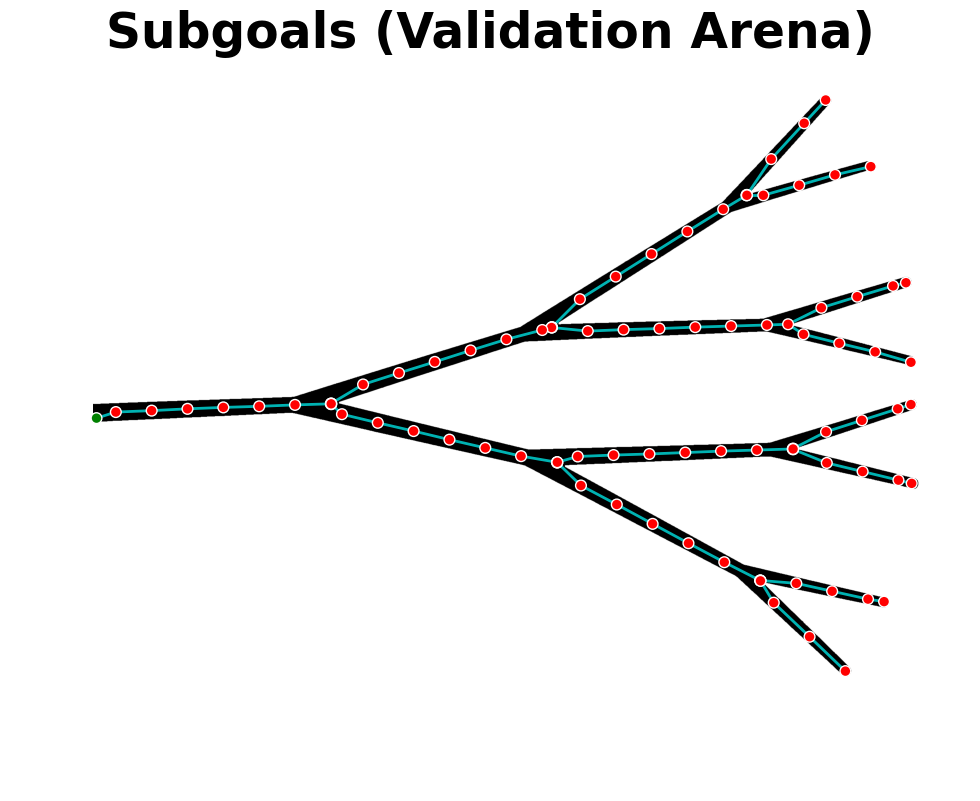

In [20]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(10, 8))
plt.imshow(image, cmap='gray')

pos = {node: (node[1], node[0]) for node in reduced_G.nodes()}

node_colors = ['green' if node == start_node else 'red' for node in reduced_G.nodes()]
nx.draw_networkx_nodes(
    reduced_G, 
    pos, 
    node_color=node_colors, 
    node_size=60, 
    edgecolors='white'
)

nx.draw_networkx_edges(
    reduced_G, 
    pos, 
    edge_color='cyan', 
    width=2, 
    alpha=0.7
)

plt.title("Subgoals (Validation Arena)", fontsize=35, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()